In [18]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("../")

In [19]:
num = "EA_2"
full_f = np.load("results/PassiveWalker-v0/"+num+"/full_f.npy")
full_x = np.load("results/PassiveWalker-v0/"+num+"/full_x.npy")
f_best = np.load("results/PassiveWalker-v0/"+num+"/100/f_best.npy")
f = np.load("results/PassiveWalker-v0/"+num+"/100/f.npy")
x_best = np.load("results/PassiveWalker-v0/"+num+"/100/x_best.npy")
x = np.load("results/PassiveWalker-v0/"+num+"/100/x.npy")

(-0.1, 1001.0)

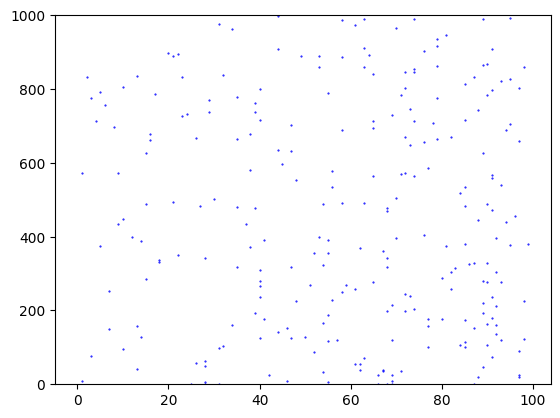

In [20]:
plt.plot(full_f, ".b", markersize=1)
plt.ylim([-0.1,1001])

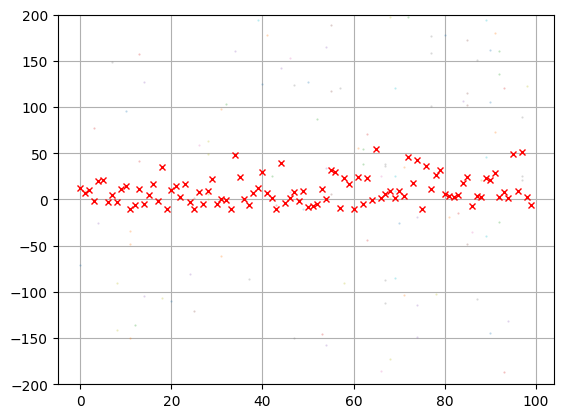

In [21]:
for i in range(len(full_f)):
    plt.plot(i*np.ones(len(full_f[i])),full_f[i], ".", markersize=1, alpha=0.3)
    plt.plot(i,np.mean(np.clip(full_f[i], -10,100000)), "x", color="red", markersize=5)
plt.ylim([-200,200])
plt.grid("on")

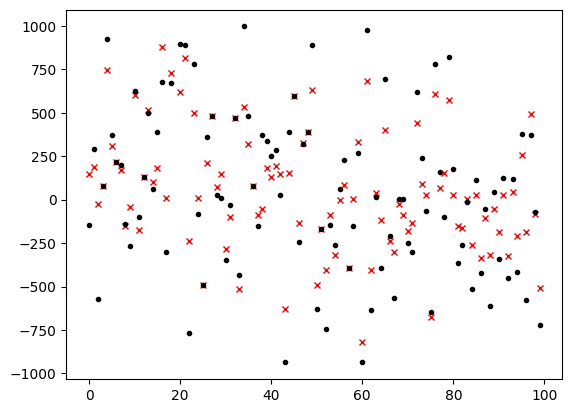

In [22]:
for i in range(full_f.shape[0]):
    vals = full_f[i]
    finite = np.isfinite(vals)          # removes -inf, +inf, nan
    # also remove values of -1000 (which is the default value for uninitialized entries)
    finite &= (vals > -999)
    v = vals[finite]

    # plt.plot(i*np.ones_like(vals), vals, ".", markersize=1, alpha=0.25)

    if v.size > 0:
        mu = v.mean(axis=0)                   # finite mean
        med = np.median(v, axis=0)              # robust center
        q25, q75 = np.quantile(v, [0.25, 0.75], axis=0)

        plt.plot(i, mu, "x", color="red", markersize=5)      # mean (finite only)
        plt.plot(i, med, "o", color="black", markersize=3)   # median
        # plt.vlines(i, q25, q75, color="black", alpha=0.4)    # IQR
# plt.ylim([-0.1,60])

In [27]:
n = 95
max_val = np.max(full_f[n])
argmax_val = np.argmax(full_f[n])
print(f"Max value at index {n}: {max_val}")
print(f"Argmax value at index {n}: {argmax_val}")
print(full_x[n,argmax_val,:])

Max value at index 95: 1945.4650890744392
Argmax value at index 95: 40
[0.5        0.5        0.09198575 0.5        0.5        0.15808311]


In [28]:
f_best, x_best

(array(2392.23190794),
 array([0.5       , 0.5       , 0.15478473, 0.5       , 0.5       ,
        0.14315835]))

In [32]:
import xml.etree.ElementTree as xml
from os.path import join
from tempfile import TemporaryDirectory

import gymnasium as gym
import numpy as np

from evorob.algorithms.es import ES, ES_opts
from evorob.utils.filesys import (
    get_distinct_filename,
    get_last_checkpoint_dir,
    get_project_root,
)
from evorob.world.base import World
from evorob.world.robot.controllers.base import Controller
from evorob.world.robot.morphology.passive_walker_robot import PassiveWalkerRobot

""" 
    Morphology optimisation: Passive-Dynamic Walker
"""

ROOT_DIR = get_project_root()
ENV_NAME = "PassiveWalker-v0"

from Introduction0b import PassiveWalkerWorld

world = PassiveWalkerWorld()
n_parameters = world.n_params

#%% Understanding the world
# TODO: can you improve the genotype - you will also need to modify the PassiveWalkerWorld class!
genotype = [0.5, 0.5, 0.13664606, 0.5, 0.5, 0.14355455] 
world.visualise_individual(genotype)

Achieved reward: 2541.914106975184
